#  Text Preprocessing

This notebook implements the full preprocessing pipeline for SemEval-2018 tweets.

We produce **two variants** of cleaned text:
- `text_clean` — aggressive cleaning (for TF-IDF, BM25, classical ML)
- `text_light` — social-media-aware light cleaning (preserves hashtags/emojis for RoBERTa)

```

## 1. Imports & Setup

In [1]:
import os
import re
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords

# Download NLTK resources (once)
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

DATA_DIR = os.path.join('..', 'data')
RAW_DIR  = os.path.join(DATA_DIR, 'semeval2018')
PROC_DIR = os.path.join(DATA_DIR, 'processed')
os.makedirs(PROC_DIR, exist_ok=True)

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

print('Imports done')

Imports done


## 2. Load Raw Data

In [2]:
df_train = pd.read_parquet(os.path.join(RAW_DIR, 'train.parquet'))
df_val   = pd.read_parquet(os.path.join(RAW_DIR, 'validation.parquet'))
df_test  = pd.read_parquet(os.path.join(RAW_DIR, 'test.parquet'))

# Πρόσθεσε ετικέτα split σε κάθε DataFrame
df_train['split'] = 'train'
df_val['split']   = 'validation'
df_test['split']  = 'test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

## 3. Preprocessing Functions

### 3a. Full Clean (`text_clean`)
Used for: **TF-IDF, BM25, Logistic Regression, SVM**

In [3]:
# Regex patterns (compiled once for speed)
URL_PATTERN      = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN  = re.compile(r'@\w+')
HASHTAG_PATTERN  = re.compile(r'#(\w+)')        # keep the word, remove #
PUNCT_PATTERN    = re.compile(r'[^\w\s]')        # remove non-word non-space
MULTI_SPACE      = re.compile(r'\s+')
NUMBERS_PATTERN  = re.compile(r'\b\d+\b')        # standalone numbers

STOP_WORDS = set(stopwords.words('english'))
TOKENIZER  = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)

def full_preprocess(text: str) -> str:
    """Aggressive cleaning for classical ML models.
    Removes URLs, mentions, punctuation, numbers, stopwords.
    Converts emojis to text descriptions.
    """
    if not isinstance(text, str):
        return ''
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = URL_PATTERN.sub('', text)
    # 3. Remove @mentions
    text = MENTION_PATTERN.sub('', text)
    # 4. Convert emojis to text (e.g. 😊 → smiling_face_with_smiling_eyes)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    # 5. Replace #hashtag → hashtag (keep the word)
    text = HASHTAG_PATTERN.sub(r'\1', text)
    # 6. Remove standalone numbers
    text = NUMBERS_PATTERN.sub('', text)
    # 7. Remove punctuation
    text = PUNCT_PATTERN.sub(' ', text)
    # 8. Tokenize with TweetTokenizer
    tokens = TOKENIZER.tokenize(text)
    # 9. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

# Test
sample = 'I LOVE #Python 🐍! Check this out: https://example.com @someone #coding'
print('Original :', sample)
print('Cleaned  :', full_preprocess(sample))

Original : I LOVE #Python 🐍! Check this out: https://example.com @someone #coding
Cleaned  : love python snake check coding


### 3b. Light Preprocessing (`text_light`)
Used for: **Sentence-Transformers (retrieval), Twitter-RoBERTa (sentiment)**

RoBERTa was fine-tuned on raw tweets — it handles hashtags and emojis natively.

In [4]:
URL_REPLACE_TOKEN     = 'URL'
MENTION_REPLACE_TOKEN = 'USER'

def light_preprocess(text: str) -> str:
    """Light social-media-aware cleaning.
    Replaces URLs and mentions with tokens.
    Keeps hashtags, emojis, and case.
    """
    if not isinstance(text, str):
        return ''
    # 1. Replace URLs with placeholder
    text = URL_PATTERN.sub(URL_REPLACE_TOKEN, text)
    # 2. Replace mentions with placeholder
    text = MENTION_PATTERN.sub(MENTION_REPLACE_TOKEN, text)
    # 3. Normalize whitespace
    text = MULTI_SPACE.sub(' ', text).strip()
    return text

# Test
print('Original :', sample)
print('Light    :', light_preprocess(sample))

Original : I LOVE #Python 🐍! Check this out: https://example.com @someone #coding
Light    : I LOVE #Python 🐍! Check this out: URL USER #coding


### 4. Apply Preprocessing Pipeline

In [5]:
print('Applying preprocessing to all tweets...')

df_all['text_clean'] = df_all['Tweet'].apply(full_preprocess)
df_all['text_light'] = df_all['Tweet'].apply(light_preprocess)

print('\nDone!')
print(f'\nTotal rows: {len(df_all):,}')

# Show side-by-side comparison
df_all[['Tweet', 'text_clean', 'text_light']].head(4)

Applying preprocessing to all tweets...



Done!

Total rows: 10,983


,Tweet,text_clean,text_light
0,“Worry is a down payment on a problem you may ...,worry payment problem may never joyce meyer mo...,“Worry is a down payment on a problem you may ...
1,Whatever you decide to do make sure it makes y...,whatever decide make sure makes happy,Whatever you decide to do make sure it makes y...
2,@Max_Kellerman it also helps that the majorit...,also helps majority nfl coaching inept bill br...,USER it also helps that the majority of NFL co...
3,Accept the challenges so that you can literall...,accept challenges literally even feel exhilara...,Accept the challenges so that you can literall...


## 5. Deduplication

In [6]:
def compute_hash(text: str) -> str:
    """MD5 hash for exact duplicate detection."""
    return hashlib.md5(text.encode('utf-8')).hexdigest()

before = len(df_all)

# Exact duplicates on the cleaned text
df_all['_hash'] = df_all['text_clean'].apply(compute_hash)
df_all = df_all.drop_duplicates(subset='_hash').drop(columns='_hash')
df_all = df_all.reset_index(drop=True)

after = len(df_all)
print(f'Before deduplication : {before:,} tweets')
print(f'After deduplication  : {after:,} tweets')
print(f'Removed              : {before - after:,} duplicates ({(before-after)/before*100:.1f}%)')

Before deduplication : 10,983 tweets
After deduplication  : 10,897 tweets
Removed              : 86 duplicates (0.8%)


## 6. Quality Checks

In [7]:
# Check for empty strings after cleaning
empty_clean = (df_all['text_clean'].str.strip() == '').sum()
empty_light = (df_all['text_light'].str.strip() == '').sum()
print(f'Empty after full clean : {empty_clean}')
print(f'Empty after light clean: {empty_light}')

# Remove rows with empty cleaned text
df_all = df_all[df_all['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'\nFinal dataset size: {len(df_all):,} tweets')

# Token length distribution
df_all['n_tokens_clean'] = df_all['text_clean'].str.split().str.len()
df_all['n_tokens_light'] = df_all['text_light'].str.split().str.len()

print(f'\nToken length stats (clean):')
print(df_all['n_tokens_clean'].describe().to_string())

Empty after full clean : 1
Empty after light clean: 0

Final dataset size: 10,896 tweets

Token length stats (clean):
count    10896.000000
mean         8.855084
std          3.880124
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         79.000000


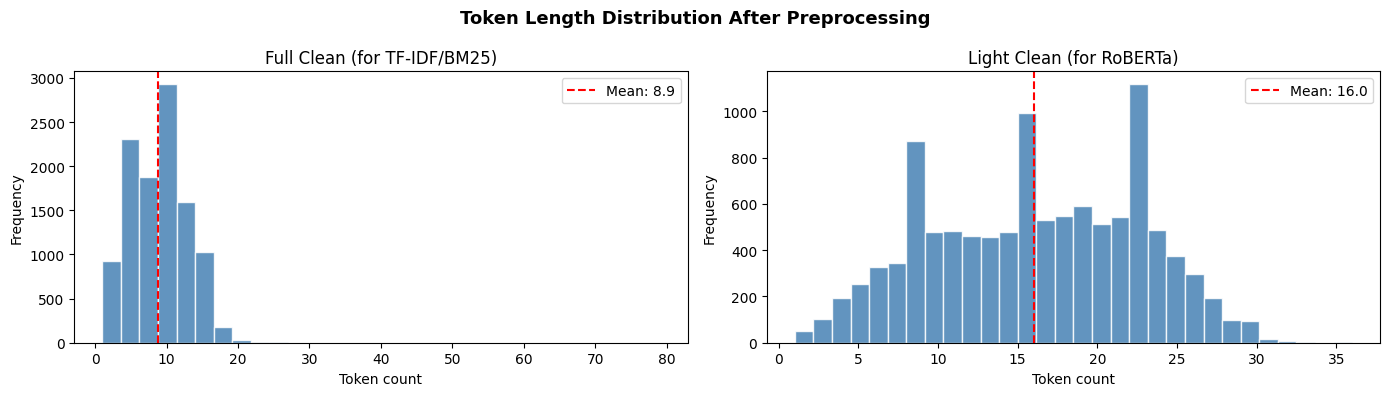

In [8]:
# Token length histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Token Length Distribution After Preprocessing', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
                           ['n_tokens_clean', 'n_tokens_light'],
                           ['Full Clean (for TF-IDF/BM25)', 'Light Clean (for RoBERTa)']):
    ax.hist(df_all[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df_all[col].mean(), color='red', linestyle='--', label=f'Mean: {df_all[col].mean():.1f}')
    ax.set_xlabel('Token count')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, 'token_length_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Most Frequent Token Analysis

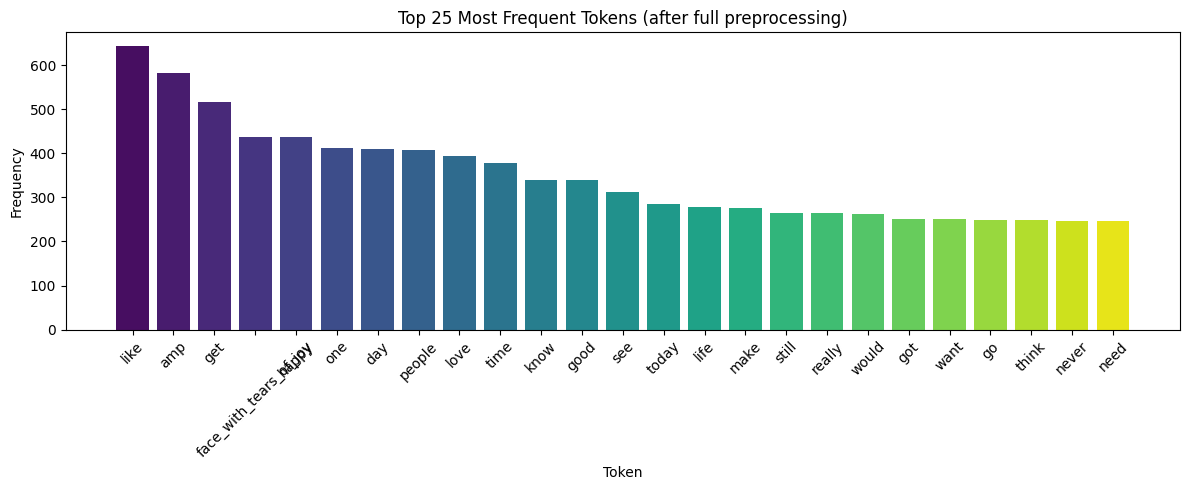

In [9]:
from collections import Counter

all_tokens = ' '.join(df_all['text_clean']).split()
token_freq = Counter(all_tokens)

top_n = 25
top_tokens = token_freq.most_common(top_n)

fig, ax = plt.subplots(figsize=(12, 5))
tokens_list, counts_list = zip(*top_tokens)
bars = ax.bar(tokens_list, counts_list, color=sns.color_palette('viridis', top_n))
ax.set_xlabel('Token')
ax.set_ylabel('Frequency')
ax.set_title(f'Top {top_n} Most Frequent Tokens (after full preprocessing)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, 'top_tokens.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-Emotion Vocabulary Peek

In [10]:
print('=== Top 10 Tokens per Emotion ===')
for emotion in EMOTIONS:
    subset = df_all[df_all[emotion] == 1]['text_clean']
    tokens = ' '.join(subset).split()
    freq = Counter(tokens)
    top = [w for w, _ in freq.most_common(10)]
    print(f'{emotion:14s}: {" | ".join(top)}')

=== Top 10 Tokens per Emotion ===
anger         : like | people | get | amp | face_with_tears_of_joy | one | angry | time | anger | know
anticipation  : get | amp | like | sparkles | start | see | want | one | would | know
disgust       : like | people | get | amp | one | face_with_tears_of_joy | time | know | really | awful
fear          : fear | anxiety | amp | nervous | terrorism | horror | afraid | nightmare | get | like
joy           : happy | face_with_tears_of_joy | love | day | amp | good | like | time | smile | one
love          : love | happy | day | smile | amp | birthday | red_heart | good | eyes | face_with_tears_of_joy
optimism      : happy | love | good | day | amp | life | get | smile | like | time
pessimism     : sad | like | get | depression | life | think | one | sadness | know | lost
sadness       : sad | like | get | amp | loudly_crying_face | people | depression | time | still | lost
surprise      : shocking | face_with_tears_of_joy | like | amp | get | know | hil

## 9. Save Processed Data

In [11]:
# Save unified processed file
out_path = os.path.join(PROC_DIR, 'tweets_processed.parquet')
df_all.to_parquet(out_path, index=False)

size_kb = os.path.getsize(out_path) / 1024
print(f' Saved to: {os.path.abspath(out_path)}')
print(f' Size   : {size_kb:.1f} KB')
print(f' Shape  : {df_all.shape}')
print(f' Columns: {list(df_all.columns)}')

 Saved to: /home/nasty/Desktop/hua/SocialMediaAgent/data/processed/tweets_processed.parquet
 Size   : 2174.9 KB
 Shape  : (10896, 18)
 Columns: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust', 'split', 'text_clean', 'text_light', 'n_tokens_clean', 'n_tokens_light']


In [12]:
# Save per-split processed files as well (for train/val/test evaluation)
for split_name in ['train', 'validation', 'test']:
    df_split = df_all[df_all['split'] == split_name]
    path = os.path.join(PROC_DIR, f'{split_name}_processed.parquet')
    df_split.to_parquet(path, index=False)
    print(f'  {split_name:12s}: {len(df_split):>5,} rows → {path}')


  train       : 6,768 rows → ../data/processed/train_processed.parquet
  validation  :   883 rows → ../data/processed/validation_processed.parquet
  test        : 3,245 rows → ../data/processed/test_processed.parquet
